In [66]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import torch
from torch.utils.data import DataLoader
from dataset import CustomDataset
from dnn_model import DnnWOTransformer
import torch.nn as nn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
from sklearn.metrics import ndcg_score
import scipy.stats as stats
import numpy as np

In [68]:
csv_path = "tables\\trkeDID_pits_over2.csv"  # replace with your actual file path
all_data = pd.read_csv(csv_path)
all_data = all_data.fillna(-1)

In [69]:
#all_data = all_data[all_data['season'] > 2018]

In [70]:
all_data.columns = all_data.columns.str.strip()
categorical_cols = ['constructor', 'driverId', 'race_name',
                                'circuit']

numerical_cols = ['season', 'round', 'position_quali', 'grid', 
                  
                  'number_of_laps', 'number_of_corners', 'lap_length', 
                  'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 
                  'WindSpeed', 'rain_bin', 'wind_direction', 
                  'last_year_time', 'avg_position_last5', 
                  'num_dnfs_last5', 'avg_gained_lost_last5', 
                  'avg_pos_last5', 'avg_pit_duration_last5',
                  'avg_pit_duration_prev_race','avg_pit_duration_prev_driver_race', 
                  'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']


numerical_cols = ['avg_gained_lost_last5',
 'avg_overtakes_prev_season_per_circuit',
 'avg_pit_duration_last5',
 'avg_pit_duration_prev_driver_race',
 'avg_pos_last5',
 'avg_position_last5',
 'grid',
 'last_year_time',
 'num_dnfs_last5']

In [71]:
target_col = 'position_race'
for col in categorical_cols:
    if all_data[col].dtype == 'object':  # ako je string tip
        all_data[col], uniques = pd.factorize(all_data[col])
        print(f"Kolona '{col}' kodirana u int. Broj unikatnih vrednosti: {len(uniques)}")

Kolona 'constructor' kodirana u int. Broj unikatnih vrednosti: 16
Kolona 'driverId' kodirana u int. Broj unikatnih vrednosti: 40
Kolona 'race_name' kodirana u int. Broj unikatnih vrednosti: 36
Kolona 'circuit' kodirana u int. Broj unikatnih vrednosti: 31


In [72]:
batch_size = 4

In [73]:
embedding_dim = 8
num_numerical = len(numerical_cols)

In [74]:
dataset = CustomDataset(all_data, target_col, numerical_cols, categorical_cols)

# Create a dataloader with batch size 1 (one race at a time)
loader_test = DataLoader(dataset, batch_size, shuffle=False)

In [75]:
embeddings_dict = {
    col: dataset.num_of_cat_features[col]
    for col in categorical_cols
}

In [76]:
hidden_dim = 256
dropout = 0
lr = 0.001

In [77]:
class ListNetLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred_scores, target_ranks):
        # Convert ranks to relevance (higher = better)
        max_rank = target_ranks.max(dim=1, keepdim=True)[0]
        relevance = max_rank - target_ranks + 1  # shape: [B, N]

        # Compute probability distributions
        true_prob = torch.softmax(relevance, dim=1)
        pred_log_prob = torch.log_softmax(pred_scores, dim=1)

        # Cross entropy between predicted and true distributions
        loss = -torch.sum(true_prob * pred_log_prob, dim=1).mean()
        return loss


In [78]:
class LambdaRank(nn.Module):
    def __init__(self, net_structures, leaky_relu=False, sigma=1.0, double_precision=False):
        """Fully Connected Layers with Sigmoid activation at the last layer

        :param net_structures: list of int for LambdaRank FC width
        """
        super(LambdaRank, self).__init__()
        self.fc_layers = len(net_structures)
        for i in range(len(net_structures) - 1):
            setattr(self, 'fc' + str(i + 1), nn.Linear(net_structures[i], net_structures[i+1]))
            if leaky_relu:
                setattr(self, 'act' + str(i + 1), nn.LeakyReLU())
            else:
                setattr(self, 'act' + str(i + 1), nn.ReLU())
        setattr(self, 'fc' + str(len(net_structures)), nn.Linear(net_structures[-1], 1))
        if double_precision:
            for i in range(1, len(net_structures) + 1):
                setattr(self, 'fc' + str(i), getattr(self, 'fc' + str(i)).double())
        self.sigma = sigma
        # self.activation = nn.Sigmoid()
        self.activation = nn.ReLU6()

    def forward(self, input1):
        # from 1 to N - 1 layer, use ReLU as activation function
        for i in range(1, self.fc_layers):
            fc = getattr(self, 'fc' + str(i))
            act = getattr(self, 'act' + str(i))
            input1 = act(fc(input1))

        fc = getattr(self, 'fc' + str(self.fc_layers))
        return self.activation(fc(input1)) * self.sigma


In [79]:
class RankNetLoss(nn.Module):
    def __init__(self):
        super(RankNetLoss, self).__init__()

    def forward(self, pred_scores, target_ranks):
        """
        pred_scores: [batch_size, num_drivers]
        target_ranks: [batch_size, num_drivers] (1 = najbolji, 20 = najgori)
        """
        batch_size, num_drivers = pred_scores.shape
        total_loss = 0.0

        for b in range(batch_size):
            scores = pred_scores[b]         # [num_drivers]
            ranks = target_ranks[b]         # [num_drivers]

            pair_loss = 0.0
            count = 0

            for i in range(num_drivers):
                for j in range(i + 1, num_drivers):
                    if ranks[i] == ranks[j]:
                        continue  # skip if ranks are same (no preference)

                    # Ground truth: 1 if i should beat j
                    S_ij = 1.0 if ranks[i] < ranks[j] else 0.0

                    s_i = scores[i]
                    s_j = scores[j]

                    pred_diff = s_i - s_j
                    prob = torch.sigmoid(pred_diff)

                    loss = - (S_ij * torch.log(prob + 1e-8) + (1 - S_ij) * torch.log(1 - prob + 1e-8))
                    pair_loss += loss
                    count += 1

            if count > 0:
                total_loss += pair_loss / count  # average over pairs

        return total_loss / batch_size


In [80]:
# Load your data
df = all_data  # change to your actual path

# Sort by season and round to ensure chronological order
df = df.sort_values(by=["season", "round"]).reset_index(drop=True)

# Get all unique races
unique_races = df[["season", "round"]].drop_duplicates().reset_index(drop=True)
num_races = len(unique_races)

# Calculate split sizes
train_size = int(num_races * 0.65)
val_size = int(num_races * 0.1)+2
test_size = num_races - train_size - val_size 

# Split the races
train_races = unique_races.iloc[:train_size]
val_races = unique_races.iloc[train_size:train_size + val_size]
test_races = unique_races.iloc[train_size + val_size:]

# Use .merge to extract rows for each split
train_df = df.merge(train_races, on=["season", "round"])
val_df = df.merge(val_races, on=["season", "round"])
test_df = df.merge(test_races, on=["season", "round"])

In [81]:
print(val_size, test_size, train_size)

16 36 96


In [82]:
dataset_train = CustomDataset(train_df, target_col, numerical_cols, categorical_cols)
dataset_val = CustomDataset(val_df, target_col, numerical_cols, categorical_cols)
dataset_test =  CustomDataset(test_df, target_col, numerical_cols, categorical_cols)


loader_test = DataLoader(dataset_test, batch_size, shuffle=False)
loader_val = DataLoader(dataset_val, batch_size, shuffle=False)
loader_train = DataLoader(dataset_train, batch_size, shuffle=False)

In [83]:
import time
import os
timern = time.time()
path = f'models_camp\\dnn\\{timern}'
os.mkdir(path)

In [84]:
model = DnnWOTransformer(embeddings_dict, num_numerical, embedding_dim, hidden_dim=hidden_dim, dropout_p=dropout)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = ListNetLoss()  
# optimizer = torch.optim.AdamW(model.parameters(), lr)
optimizer = torch.optim.SGD(model.parameters(), lr)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

val_loss_list = []
ndcg_train = []
loss_list_train = []
loss_list_train = []
ndcg_values_valid = []
ndcg_values_valid_one_epoch = []


In [85]:
num_epochs = 50 + 1

In [86]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    ndcg_values = []
    #ndcg_values_valid = []
    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_train):
        cat_features = {k: v.to(device) for k, v in cat_features.items()}
        num_tensor = num_tensor.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = model(cat_features, num_tensor)  # [batch, 20, 1]
        scores = output.squeeze(-1)               # [batch, 20]

        # target su već rangovi (1 je najbolji), koristi direktno
        loss = criterion(scores, target)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        true_rank_np = target.cpu().numpy()
        scores_np = scores.cpu().detach().numpy()

        # Invertujemo rang: pozicija 1 → 20, pozicija 20 → 1
        true_relevance = 21 - true_rank_np

        # Računamo ndcg po trci i uzimamo prosek
        

        for i in range(true_relevance.shape[0]):
            ndcg = ndcg_score([true_relevance[i]], [scores_np[i]], k=10)  # možeš i k=None za ceo poredak
            ndcg_values.append(ndcg)

    avg_loss = running_loss / len(loader_train)
    avg_ndcg = sum(ndcg_values) / len(ndcg_values)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, NDCG: {avg_ndcg:.4f}")


    loss_list_train.append(avg_loss)
    ndcg_train.append(avg_ndcg)



    model.eval()
    val_loss = 0.0
    ndcg_values_valid_one_epoch = []

    with torch.no_grad():
        for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_val):
            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor).squeeze(-1)  # [batch, 20]
            loss = criterion(output, target)
            val_loss += loss.item()

            scores_np = output.cpu().numpy()
            true_rank_np = target.cpu().numpy()
            true_relevance = 21 - true_rank_np

            for i in range(true_relevance.shape[0]):
                ndcg = ndcg_score([true_relevance[i]], [scores_np[i]], k=10)
                ndcg_values_valid_one_epoch.append(ndcg)

    avg_val_loss = val_loss / len(loader_val)
    avg_ndcg_valid = sum(ndcg_values_valid_one_epoch) / len(ndcg_values_valid_one_epoch)
    
    print(f"Validacioni loss: {avg_val_loss:.4f}")
    print(f"Validacioni NDCG: {avg_ndcg_valid:.4f}")

    # val_loss_list.append(avg_val_loss)
    # ndcg_values_valid.append(avg_ndcg_valid)

    ndcg_valid = ndcg / len(loader_val)
    avg_val_loss = val_loss / len(ndcg_values_valid_one_epoch)
    
    ndcg_values_valid.append(ndcg_valid)
    val_loss_list.append(avg_val_loss)

    
    if epoch % 5 == 0:
        torch.save(model.state_dict(), os.path.join(path, f'{epoch}.pth'))
        print(f'Saved to models {epoch}.pth')



Epoch 1/51, Loss: 2.9993, NDCG: 0.6423
Validacioni loss: 3.0017
Validacioni NDCG: 0.5477
Saved to models 0.pth
Epoch 2/51, Loss: 2.9949, NDCG: 0.6951
Validacioni loss: 2.9964
Validacioni NDCG: 0.5877
Epoch 3/51, Loss: 2.9907, NDCG: 0.7660
Validacioni loss: 2.9922
Validacioni NDCG: 0.7688
Epoch 4/51, Loss: 2.9865, NDCG: 0.7770
Validacioni loss: 2.9882
Validacioni NDCG: 0.7653
Epoch 5/51, Loss: 2.9825, NDCG: 0.7410
Validacioni loss: 2.9844
Validacioni NDCG: 0.6821
Epoch 6/51, Loss: 2.9786, NDCG: 0.7375
Validacioni loss: 2.9804
Validacioni NDCG: 0.6889
Saved to models 5.pth
Epoch 7/51, Loss: 2.9745, NDCG: 0.7414
Validacioni loss: 2.9766
Validacioni NDCG: 0.6908
Epoch 8/51, Loss: 2.9706, NDCG: 0.7445
Validacioni loss: 2.9729
Validacioni NDCG: 0.7105
Epoch 9/51, Loss: 2.9667, NDCG: 0.7478
Validacioni loss: 2.9694
Validacioni NDCG: 0.7107
Epoch 10/51, Loss: 2.9630, NDCG: 0.7489
Validacioni loss: 2.9662
Validacioni NDCG: 0.7131
Epoch 11/51, Loss: 2.9593, NDCG: 0.7520
Validacioni loss: 2.9628


In [87]:
len(dataset_train)

96

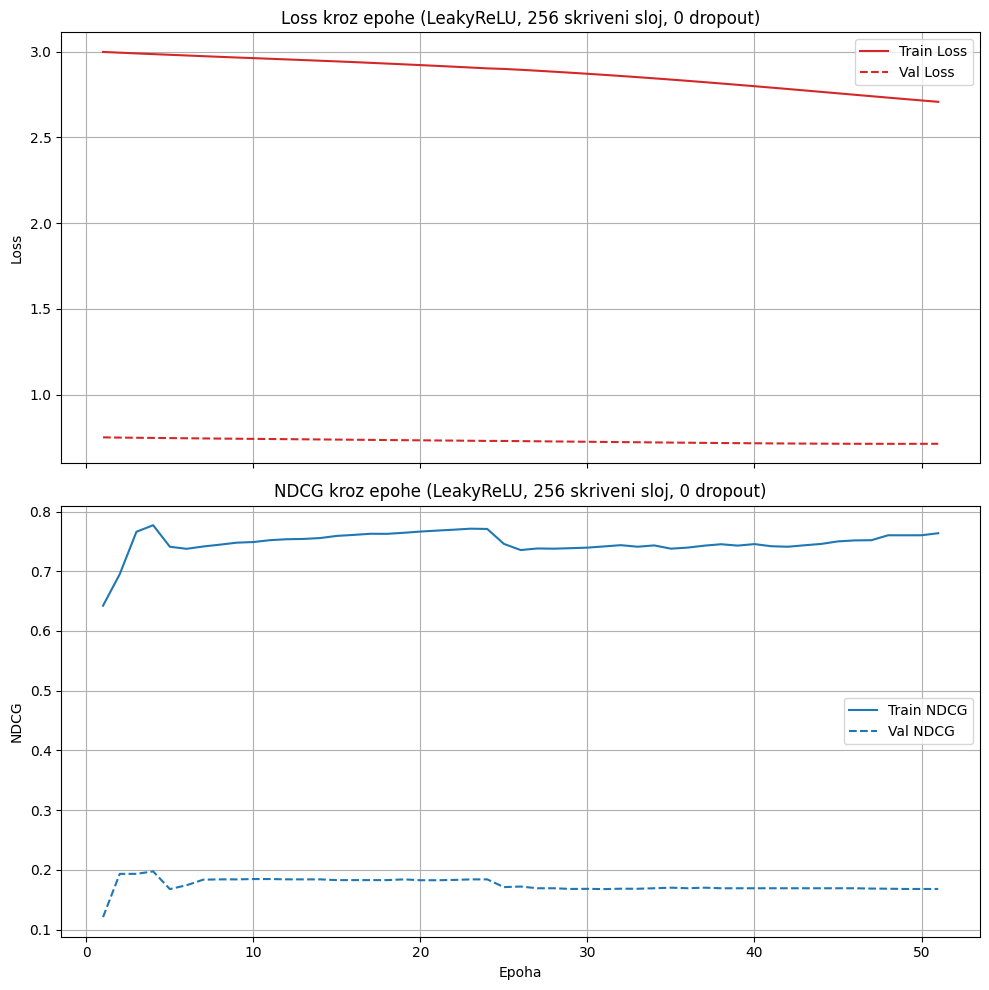

In [88]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(loss_list_train) + 1))

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Prvi subplot – Loss
axs[0].plot(epochs, loss_list_train, label='Train Loss', color='tab:red', linestyle='-')
axs[0].plot(epochs, val_loss_list, label='Val Loss', color='tab:red', linestyle='--')
axs[0].set_ylabel('Loss')
axs[0].set_title(f'Loss kroz epohe (LeakyReLU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[0].legend()
axs[0].grid(True)

# Drugi subplot – NDCG
axs[1].plot(epochs, ndcg_train, label='Train NDCG', color='tab:blue', linestyle='-')
axs[1].plot(epochs, ndcg_values_valid, label='Val NDCG', color='tab:blue', linestyle='--')
axs[1].set_xlabel('Epoha')
axs[1].set_ylabel('NDCG')
axs[1].set_title(f'NDCG kroz epohe (LeakyReLU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [89]:
fig.savefig(os.path.join(path, 'metrike.jpg'))

In [90]:
from scipy import stats
import numpy as np
from sklearn.metrics import ndcg_score

# Pomerimo sve na CPU i u NumPy
true_rank_np = target.cpu().numpy()  # [batch, 20]
scores_np = scores.cpu().detach().numpy()  # [batch, 20]

# Invertujemo rang: pozicija 1 → 20, pozicija 20 → 1
true_relevance = 21 - true_rank_np

ndcg_values = []
tau_list = []
spearman_list = []

for i in range(true_relevance.shape[0]):
    ndcg = ndcg_score([true_relevance[i]], [scores_np[i]], k=10)
    ndcg_values.append(ndcg)

    # Ove dve linije su bile pogrešne – treba koristiti po-trci podatke
    tau, _ = stats.kendalltau(true_rank_np[i], -scores_np[i])
    spearman, _ = stats.spearmanr(true_rank_np[i], -scores_np[i])
    tau_list.append(tau)
    spearman_list.append(spearman)

avg_ndcg = np.mean(ndcg_values)
avg_tau = np.nanmean(tau_list)
avg_spearman = np.nanmean(spearman_list)

print(f"Average NDCG@10: {avg_ndcg:.4f}")
print(f"Average Kendall's Tau: {avg_tau:.4f}")
print(f"Average Spearman: {avg_spearman:.4f}")


Average NDCG@10: 0.6185
Average Kendall's Tau: 0.0000
Average Spearman: -0.0054


In [91]:
model.eval()
with torch.no_grad():
    # Uzmemo samo prvi batch — prva trka
    cat_features, num_tensor, target, drivers_num, position_quali = next(iter(loader_val))

    cat_features = {k: v.to(device) for k, v in cat_features.items()}
    num_tensor = num_tensor.to(device)
    target = target.to(device)

    output = model(cat_features, num_tensor).squeeze(-1)
    scores = output.cpu().numpy()[0]
    true_ranks = target.cpu().numpy()[0]
    quali_pos = position_quali.numpy()[0]
    driver_ids = drivers_num.numpy()[0]

    # Predviđeni poredak na osnovu najnižeg skora
    pred_order = scores.argsort()  # indeks pozicija od najboljeg ka najgorem
    print("\nPoređenje za jednu trku:\n")
    print(f"{'Poz':<5}{'Vozač':<10}{'Stvarna':<10}{'Predviđena':<12}{'Kvalifikacije':<15}")
    for pos, idx in enumerate(pred_order):
        print(f"{pos+1:<5}{driver_ids[idx]:<10}{true_ranks[idx]:<10}{pos+1:<12}{quali_pos[idx]:<15}")



Poređenje za jednu trku:

Poz  Vozač     Stvarna   Predviđena  Kvalifikacije  
1    33        1.0       1           2              
2    44        5.0       2           5              
3    21        9.0       3           13             
4    20        16.0      4           19             
5    24        10.0      5           14             
6    10        8.0       6           9              
7    22        14.0      7           15             
8    3         17.0      8           8              
9    4         7.0       9           7              
10   77        13.0      10          12             
11   16        2.0       11          1              
12   11        6.0       12          4              
13   55        4.0       13          3              
14   18        18.0      14          18             
15   14        19.0      15          10             
16   63        3.0       16          6              
17   31        11.0      17          11             
18   6         15.0